# IAAA1 - TP3
#### Nicolás Druetta - DNI: 36604286

&nbsp;

**Dos referencias para interpretar mejor mi Colab:**

---

Comentarios míos entre `<hr/>` en las celdas de Texto.

---

In [340]:
## Comentarios míos con doble ## en las celdas de Código.

---

# Regularización Ridge, Lasso y Elastic Net con Python

La **regularización** es una técnica que se utiliza para evitar que un modelo aprenda “demasiado” los datos de entrenamiento. Cuando un modelo tiene muchas variables o relaciones complejas, puede empezar a memorizar detalles específicos y ruido de los datos en lugar de aprender patrones reales. A esto se lo conoce como *overfitting*. El problema es que el modelo parece funcionar perfecto durante el entrenamiento, pero falla cuando recibe datos nuevos. Para evitarlo, la regularización agrega una “penalización” a los coeficientes del modelo y obliga a que sean más pequeños y simples.

* **Ridge (L2):**
  Ridge reduce el tamaño de los coeficientes, pero nunca los lleva exactamente a cero. Esto significa que mantiene todas las variables del modelo, aunque con menos influencia. Es muy útil cuando existen variables muy parecidas o correlacionadas entre sí, porque ayuda a estabilizar el modelo y evitar valores exagerados en los coeficientes.

* **Lasso (L1):**
  Lasso también reduce coeficientes, pero además puede hacer que algunos valgan exactamente cero. Cuando eso ocurre, esas variables quedan fuera del modelo. Por eso, Lasso no solo regulariza, sino que también realiza una selección automática de variables, dejando únicamente las más importantes.

* **Elastic Net:**
  Elastic Net combina las ideas de Ridge y Lasso. Reduce coeficientes como Ridge y también puede eliminar variables como Lasso. Se utiliza mucho cuando hay muchas variables correlacionadas y se busca un equilibrio entre estabilidad y simplificación del modelo.

* **Lambda (λ):**
  Lambda es el parámetro que controla qué tan fuerte es la regularización. Si λ es pequeño, la penalización casi no afecta al modelo y este se comporta parecido a una regresión normal. Si λ es grande, los coeficientes se reducen mucho más y el modelo se vuelve más simple. En otras palabras, λ controla cuánto se “castiga” la complejidad del modelo.
  
---

# Ejemplo regresión
El departamento de calidad de una empresa de alimentación se encarga de medir el contenido en grasa de la carne que comercializa. Este estudio se realiza mediante técnicas de analítica química, un proceso relativamente costoso en tiempo y recursos. Una alternativa que permitiría reducir costes y optimizar tiempo es emplear un espectrofotómetro (instrumento capaz de detectar la absorbancia que tiene un material a diferentes tipos de luz en función de sus características) e inferir el contenido en grasa a partir de sus medidas.

Antes de dar por válida esta nueva técnica, la empresa necesita comprobar qué margen de error tiene respecto al análisis químico. Para ello, se mide el espectro de absorbancia a 100 longitudes de onda en 215 muestras de carne, cuyo contenido en grasa se obtiene también por análisis químico, y se entrena un modelo con el objetivo de predecir el contenido en grasa a partir de los valores dados por el espectrofotómetro.

Los datos meatspec.csv empleados en este ejemplo se han obtenido del magnífico libro Linear Models with R, Second Edition.

# Librerías
Las librerías utilizadas en este ejemplo son:

In [341]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8
import seaborn as sns

# Preprocesado y modelado
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

# Datos
El set de datos contiene 101 columnas. Las 100 primeras recogen el valor de absorbancia para cada una de las 100 longitudes de onda analizadas (predictores), y la columna fat el contenido en grasa medido por técnicas químicas (variable respuesta).

In [342]:
# Datos
# ==============================================================================
datos = pd.read_csv('https://raw.githubusercontent.com/frandiego/data/master/meatspec.csv')
datos = datos.drop(columns = datos.columns[0])
datos.info()
datos.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Columns: 101 entries, V1 to fat
dtypes: float64(101)
memory usage: 169.8 KB


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,fat
0,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,2.62722,...,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920,22.5
1,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,2.87661,...,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942,40.1
2,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,2.60131,...,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816,8.4


# Relación entre variables
El primer paso a la hora de establecer un modelo lineal múltiple es estudiar la relación que existe entre variables. Esta información es crítica a la hora de identificar cuáles pueden ser los mejores predictores para el modelo, y para detectar colinealidad entre predictores. A modo complementario, es recomendable representar la distribución de cada variable mediante histogramas.

In [343]:
# Correlación entre columnas numéricas
# ==============================================================================

def tidy_corr_matrix(corr_mat):
    '''
    Función para convertir una matriz de correlación de pandas en formato tidy
    '''
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1','variable_2','r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)

    return(corr_mat)

corr_matrix = datos.select_dtypes(include=['float64', 'int']) \
              .corr(method='pearson')
display(tidy_corr_matrix(corr_matrix).head(5))

,variable_1,variable_2,r,abs_r
1019,V11,V10,0.999996,0.999996
919,V10,V11,0.999996,0.999996
1121,V12,V11,0.999996,0.999996
1021,V11,V12,0.999996,0.999996
917,V10,V9,0.999996,0.999996


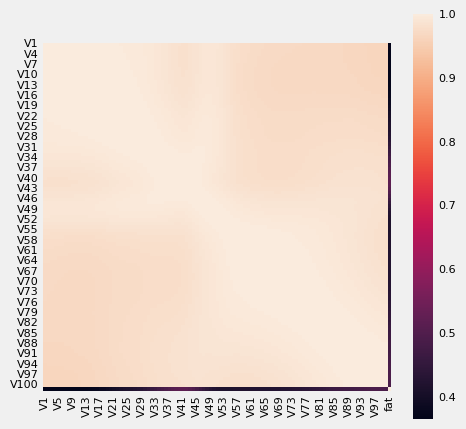

In [344]:
# Heatmap matriz de correlaciones
# ==============================================================================
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
sns.heatmap(
    data      = corr_matrix,
    square    = True,
    ax        = ax
)
ax.tick_params(labelsize=8)

Muchas de las variables están altamente correlacionadas (correlación absoluta > 0.8), lo que supone un problema a la hora de emplear modelos de regresión lineal.

# Partición de datos
En los siguientes apartados se ajustan varios modelos lineales con y sin regularización, con el objetivo de identificar cuál de ellos es capaz de predecir mejor el contenido en grasa de la carne en función de las señales registradas por el espectrofotómetro.

Para poder evaluar la capacidad predictiva de cada modelo, se dividen las observaciones disponibles en dos grupos: uno de entrenamiento (70%) y otro de test (30%).

In [345]:
# División de los datos en train y test
# ==============================================================================
X = datos.drop(columns='fat')
y = datos['fat']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size   = 0.7,
    random_state = 1234,
    shuffle      = True
)

# Escalado
Los modelos de regresión lineal con regularización Ridge, Lasso y Elastic Net penalizan la magnitud de los coeficientes del modelo, por lo que es necesario que todos los predictores estén en la misma escala. Para ello, se puede emplear estandarización o normalización. En este ejemplo se utiliza estandarización.

In [346]:
# Escalado
# ==============================================================================
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Mínimos cuadrados (OLS)
Los Mínimos Cuadrados Ordinarios (OLS) se utilizan para entrenar modelos de regresión lineal capaces de predecir valores numéricos a partir de distintas variables de entrada. El método ajusta una recta que minimiza el error entre los valores reales y los valores predichos por el modelo, permitiendo analizar relaciones y realizar estimaciones sobre nuevos datos.

In [347]:
# Creación y entrenamiento del modelo
# ==============================================================================
modelo = LinearRegression()
modelo.fit(X=X_train, y=y_train)

LinearRegression()

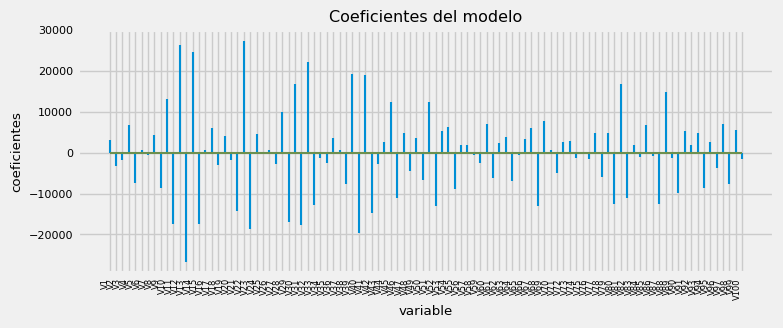

In [348]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,
    'coef': modelo.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [349]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([36.88226752, 62.47992661, 61.04825535,  9.95161352, 18.11993067,
        6.56158193, 28.42860453,  9.18085599, 15.56800749, 16.50461443])

In [350]:
# Error de test del modelo
# ==============================================================================
rmse_ols = root_mean_squared_error(
            y_true  = y_test,
            y_pred  = predicciones,
           )
print(f"El error (rmse) de test es: {rmse_ols}")

El error (rmse) de test es: 3.8396675856299343


In [351]:
predictores_ols = X_train.shape[1]

Las predicciones del modelo final se alejan en promedio 3.84 unidades del valor real.

# Ridge

In [352]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# ==============================================================================
# Por defecto RidgeCV utiliza el neg mean squared error
modelo = RidgeCV(
    ## Genera 200 valores posibles de alpha entre 10^-20 y 10^2.
    alphas           = np.logspace(-20, 2, 200),
    scoring          ='neg_root_mean_squared_error',
    fit_intercept    = True,
    store_cv_results = True
)

_ = modelo.fit(X = X_train, y = y_train)

---

**¿Qué hace RidgeCV?**

Prueba automáticamente TODOS los alpha.

Para cada alpha:

* entrena un modelo.
* evalúa qué tan bien predice.
* calcula el error.
* compara resultados.

Y finalmente se queda con el mejor.

---

Cuando se utiliza regularización, es útil evaluar cómo se aproximan a cero los coeficientes a medida que se incrementa el valor de alpha así como la evolución del error de validación cruzada en función del alpha empleado.

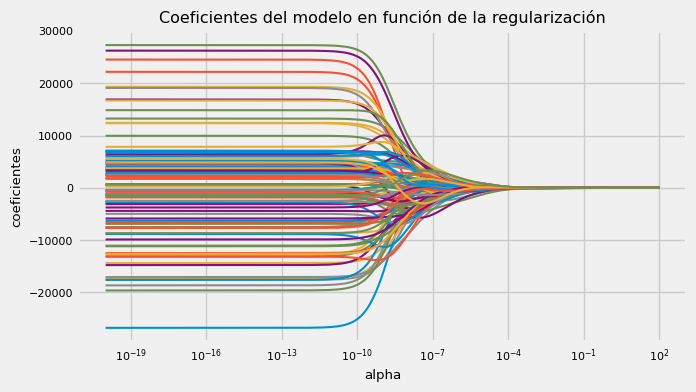

In [353]:
# Evolución de los coeficientes en función de alpha
# ==============================================================================
alphas = modelo.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');
plt.axis('tight')
plt.show()

---

**La idea de Ridge es encontrar un equilibrio:**

* hacia la izquierda del gráfico, alpha es muy chico, casi no hay regularización y el modelo tiene demasiada libertad, por lo que puede memorizar los datos (*overfitting*).
* hacia la derecha, alpha es más grande, la regularización aumenta y los coeficientes se reducen, haciendo que el modelo sea más simple y aprenda menos (*underfitting*).

Entonces Ridge intenta encontrar un valor de alpha intermedio que permita al modelo aprender los patrones importantes sin exagerar.

---

Puede verse como, a medida que aumenta el valor de alpha, la regularización es mayor y el valor de los coeficientes se reduce.

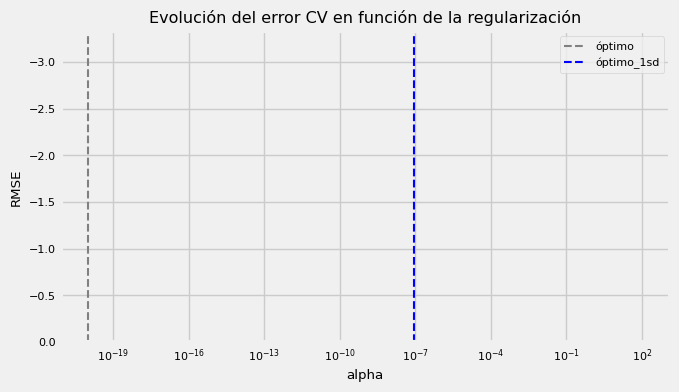

In [354]:
# Evolución del error en función de alpha
# ==============================================================================
# modelo.cv_results_ almacena el resultado de cv para cada valor de alpha.
# Tiene dimensiones (n_samples, n_alphas) o (n_samples, n_targets, n_alphas)
cv_results = modelo.cv_results_
# Se multiplica por -1 para obtener el RMSE positivo
rmse_cv = -1 * cv_results.mean(axis=0)
rmse_sd = cv_results.std(axis=0)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas[np.argmin(rmse_cv)].item()
optimo_1sd   = modelo.alphas[rmse_cv == min_rmse_1sd].item()

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(modelo.alphas, rmse_cv)
ax.fill_between(
    modelo.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)
ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend();

In [355]:
# Mejor valor alpha encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")
print("Esto significa: 5,0526310653357 × 10^-6.")

Mejor valor de alpha encontrado: 5.0526310653357e-06
Esto significa: 5,0526310653357 × 10^-6.


---

**¿Qué es exactamente Cross Validation (CV)?**

Cross Validation es una técnica para evaluar el modelo varias veces usando diferentes divisiones de los datos. En cada iteración, una parte de los datos se usa para entrenar y otra para probar el modelo.

Esto se hace para:

* verificar si el modelo realmente generaliza bien.
* evitar que el resultado dependa de una única división del dataset.
* evitar que el modelo parezca bueno solo porque “tuvo suerte” con una división específica de los datos.

Al final, se promedian todos los resultados y se elige la configuración que mejor predice sobre datos nuevos.

---

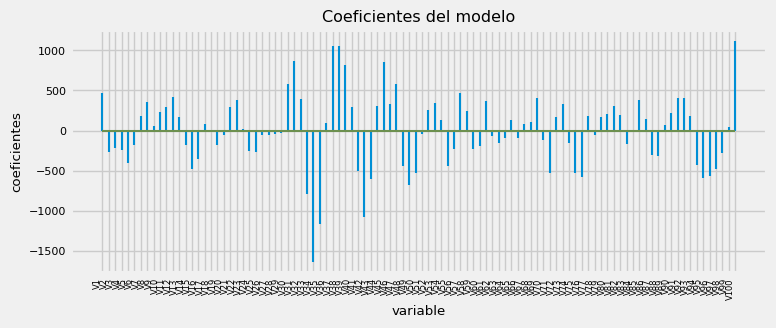

In [356]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,
    'coef': modelo.coef_.flatten()
})

fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

En comparación al modelo por mínimos cuadrados ordinarios, con ridge, el orden de magnitud de los coeficientes es mucho menor.

In [357]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([43.18344348, 40.77188673, 51.13840201,  9.98568524, 17.87646593,
        7.6652655 , 28.10025725,  8.19516261, 14.7508043 , 14.43546212])

In [358]:
# Error de test del modelo
# ==============================================================================
rmse_ridge = root_mean_squared_error(
                y_true  = y_test,
                y_pred  = predicciones,
             )
print(f"El error (rmse) de test es: {rmse_ridge}")

El error (rmse) de test es: 2.3915887532773366


In [359]:
predictores_ridge = np.sum(modelo.coef_ != 0)

Las predicciones del modelo final se alejan en promedio 2.39 unidades del valor real. (Bien, mejoró).

# Lasso

In [360]:
# Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)
# ==============================================================================
# Por defecto LassoCV utiliza el mean squared error
modelo = LassoCV(
    alphas = np.logspace(-5, 3, 200), ## np.logspace(-20, 2, 200), ##
    cv     = 5,
)
_ = modelo.fit(X = X_train, y = y_train)

Cuando se utiliza regularización, es útil evaluar cómo se aproximan a cero los coeficientes a medida que se incrementa el valor de alpha así como la evolución del error de validación cruzada en función del alpha empleado.

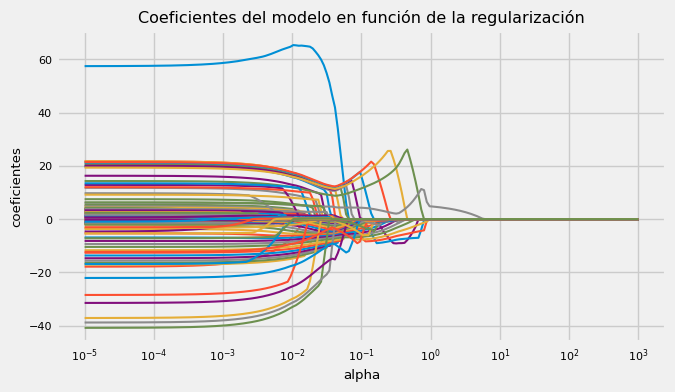

In [361]:
# Evolución de los coeficientes en función de alpha
# ==============================================================================
alphas = modelo.alphas_
coefs = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');

---

**Comportamiento de los coeficientes**

* En Ridge, las líneas se acercan mucho a 0, pero siguen visibles porque los coeficientes no llegan exactamente a 0.
* En Lasso, varias líneas desaparecen del gráfico porque sus coeficientes sí llegan exactamente a 0.

---

Puede ver se como, a medida que aumenta el valor de alpha, la regularización es mayor y más predictores quedan excluidos (su coeficiente es 0).

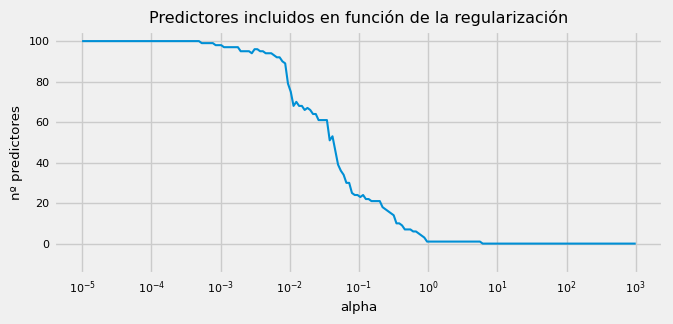

In [362]:
# Número de predictores incluidos (coeficiente !=0) en función de alpha
# ==============================================================================
alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=True)
    modelo_temp.fit(X_train, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-15,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº predictores')
ax.set_title('Predictores incluidos en función de la regularización');

---

Este gráfico muestra:

“Cuántos predictores siguen activos a medida que aumenta alpha.”

* **Predictores** = variables de entrada.
* **Coeficientes** = pesos que el modelo le asigna a cada predictor.

---

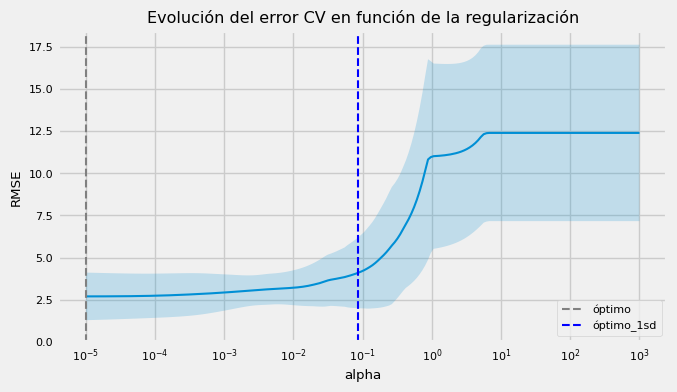

In [363]:
# Evolución del error en función de alpha
# ==============================================================================
# modelo.mse_path_ almacena el mse de cv para cada valor de alpha. Tiene
# dimensiones (n_alphas, n_folds)
mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas_[rmse_cv == min_rmse_1sd]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimo_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend();

---

**¿Qué pasa en el gráfico?**

Izquierda:

* Alpha pequeño.
* El error es bajo.
* El modelo predice bien.

Derecha: lo contrario.

---

In [364]:
# Mejor valor alpha encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 1e-05


In [365]:
 # Mejor valor alpha encontrado + 1sd
# ==============================================================================
min_rmse     = np.min(rmse_cv)
sd_min_rmse  = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimo       = modelo.alphas_[np.argmin(rmse_cv)]
optimo_1sd   = modelo.alphas_[rmse_cv == min_rmse_1sd].item()

print(f"Mejor valor de alpha encontrado + 1 desviación estándar: {optimo_1sd}")

Mejor valor de alpha encontrado + 1 desviación estándar: 0.08703591361485166


---

La regla de **1 desviación estándar (1sd)** dice algo como:

“En vez de elegir el modelo con el error mínimo exacto, elegí el modelo más simple cuyo error siga siendo suficientemente parecido al mejor.”

> En la práctica:
>
> `error mínimo = 2.50`
> `desviación estándar = 0.30`
>
> Entonces se aceptan modelos con error hasta:
>
> `2.50 + 0.30 = 2.80`
>
> Y entre todos esos modelos, se elige el más simple (normalmente el de mayor alpha).

La idea es:

“Si un modelo mucho más simple predice casi igual de bien, conviene quedarse con el más simple."

---

Se entrena de nuevo el modelo, esta vez empleando el mayor valor de alpha cuyo error está a menos de una desviación típica del mínimo encontrado en la validación cruzada.

In [366]:
# Mejor modelo alpha óptimo + 1sd
# ==============================================================================
modelo = Lasso(alpha=optimo_1sd)
modelo.fit(X_train, y_train)

Lasso(alpha=0.08703591361485166)

In [367]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,
    'coef': modelo.coef_.flatten()
})

# Predictores incluidos en el modelo (coeficiente != 0)
df_coeficientes[df_coeficientes.coef != 0].reset_index(drop=True)

,predictor,coef
0,V8,-2.809618
1,V9,-7.678029
2,V10,-6.773139
3,V11,-6.028624
4,V12,-5.284843
5,V13,-4.547397
6,V14,-3.780134
7,V15,-3.064607
8,V16,-2.425411
9,V17,-1.873268


De los 100 predictores disponibles, el modelo final solo incluye 24.

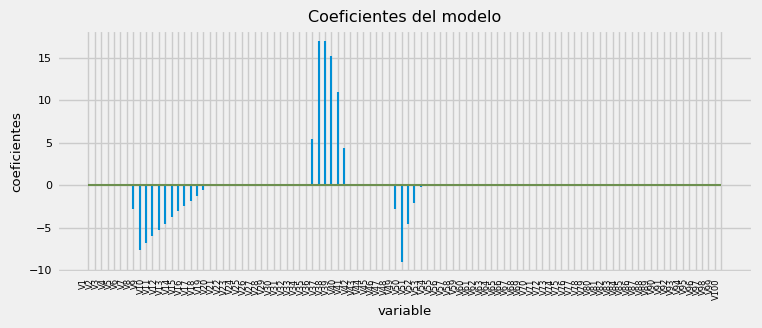

In [368]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

In [369]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([34.35041421, 53.75222685, 36.17366435, 11.74672533, 15.1183471 ,
        6.35327526, 24.5488085 ,  7.48191556, 13.46044097, 18.71293633])

In [370]:
# Error de test del modelo
# ==============================================================================
rmse_lasso = root_mean_squared_error(
    y_true = y_test,
    y_pred = predicciones
)
print("")
print(f"El error (rmse) de test es: {rmse_lasso}")


El error (rmse) de test es: 3.747834638323956


In [371]:
predictores_lasso = np.sum(modelo.coef_ != 0)

Las predicciones del modelo final se alejan en promedio 3.95 unidades del valor real, utilizando solo 24 de los 100 predictores disponibles. (Empeoró un poquito).

# Elastic net

In [372]:
# Creación y entrenamiento del modelo con búsqueda por CV del mejor alpha y l1_ratio.
# ==============================================================================
# Por defecto ElasticNetCV utiliza el mean squared error.
modelo = ElasticNetCV(
    ## Define qué proporción de la regularización corresponde a Lasso.
    ## Valores cercanos a 0 se comportan más como Ridge.
    ## Valores cercanos a 1 se comportan más como Lasso.
    ## ElasticNetCV prueba todos estos valores y elige la mezcla que mejor predice.
    l1_ratio = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],

    ## Genera 200 valores posibles de alpha entre 10^-10 y 10^3.
    alphas   = np.logspace(-10, 3, 200), ## np.logspace(-20, 2, 200), ##

    ## Divide los datos en 5 partes para hacer validación cruzada.
    ## Esto permite evaluar el modelo varias veces con distintas divisiones.
    cv       = 5
)

## Entrena el modelo con los datos de entrenamiento.
## Durante el entrenamiento, prueba las combinaciones de alpha y l1_ratio.
## Finalmente, se queda con la combinación que obtiene el menor error promedio.
_ = modelo.fit(X = X_train, y = y_train)

In [373]:
# Evolución del error en función de alpha y l1_ratio
# ==============================================================================
# modelo.mse_path_ almacena el mse de cv para cada valor de alpha y l1_ratio.
# Tiene dimensiones (n_l1_ratio, n_alpha, n_folds)

# Error medio de las 10 particiones por cada valor de alpha y l1_ratio
mean_error_cv = modelo.mse_path_.mean(axis=2)

# El resultado es un array de dimensiones (n_l1_ratio, n_alpha)
# Se convierte en un dataframe
df_resultados_cv = pd.DataFrame(
    data   = mean_error_cv.flatten(),
    index  = pd.MultiIndex.from_product(
        iterables = [modelo.l1_ratio, modelo.alphas_],
        names     = ['l1_ratio', 'modelo.alphas_']
    ),
    columns = ["mse_cv"]
)

df_resultados_cv['rmse_cv'] = np.sqrt(df_resultados_cv['mse_cv'])
df_resultados_cv = df_resultados_cv.reset_index().sort_values('mse_cv', ascending = True)
df_resultados_cv

,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
1351,0.99,1.366716e-07,7.313915,2.704425
1352,0.99,1.175850e-07,7.313916,2.704425
1350,0.99,1.588565e-07,7.313945,2.704431
1353,0.99,1.011638e-07,7.313964,2.704434
1349,0.99,1.846425e-07,7.313992,2.704439
...,...,...,...,...
628,0.70,1.482021e+01,153.374640,12.384452
627,0.70,1.722586e+01,153.374640,12.384452
629,0.70,1.275051e+01,153.374640,12.384452
630,0.70,1.096986e+01,153.374640,12.384452


---

**Resultados de Cross Validation en Elastic Net**

Esta tabla muestra todas las combinaciones de l1_ratio y alpha que probó ElasticNetCV.

Cada fila representa una combinación distinta:

* **l1_ratio**: define la mezcla entre Ridge y Lasso.
  * Si está cerca de 0, el modelo se parece más a Ridge.
  * Si está cerca de 1, el modelo se parece más a Lasso.

* **modelo.alphas_**: indica la fuerza de la regularización.
  * Si alpha es chico, hay poca regularización.
  * Si alpha es grande, los coeficientes se reducen más y el modelo se vuelve más simple.

* **mse_cv**: muestra el error promedio obtenido en Cross Validation.
  * Mientras más bajo sea este valor, mejor predijo el modelo.

* **rmse_cv**: es la raíz cuadrada del MSE.
  * También mide error, pero en una escala más fácil de interpretar.
  * Mientras más bajo sea, mejor.

Como la tabla está ordenada de menor a mayor error, las primeras filas muestran las combinaciones que mejor predijeron. En este caso, los mejores resultados aparecen con l1_ratio = 0.99, **por lo que el modelo se comporta casi como Lasso**.

---

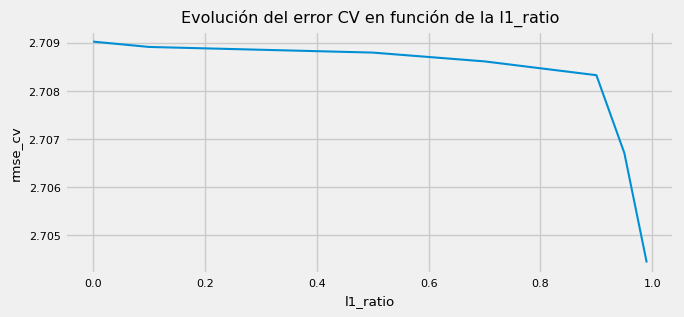

In [374]:
# Mejor valor encontrado para cada l1_ratio
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
df_resultados_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');

In [375]:
# Mejor valor alpha y l1_ratio_ encontrado
# ==============================================================================
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {modelo.l1_ratio_}")

Mejor valor de alpha encontrado: 1.3667163564620074e-07
Mejor valor de l1_ratio encontrado: 0.99


In [376]:
# Coeficientes del modelo
# ==============================================================================
df_coeficientes = pd.DataFrame({
    'predictor': X_train.columns,
    'coef': modelo.coef_.flatten()}
)

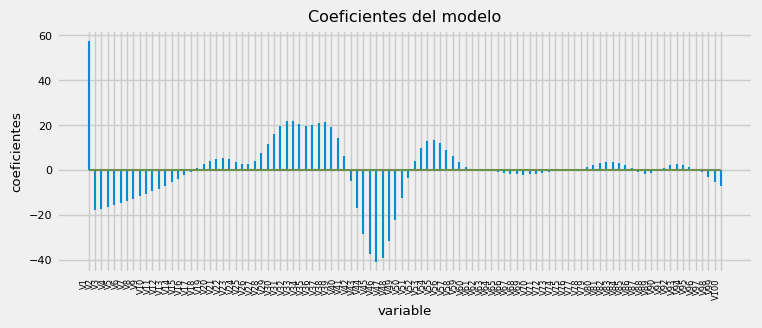

In [377]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');

---

**Coeficientes del modelo**

Este gráfico muestra los coeficientes que el modelo asigna a cada variable. Puede pensarse como una fórmula gigante donde cada variable tiene un número asociado que indica cuánto influye en la predicción final.

* Si el coeficiente es positivo, esa variable empuja la predicción hacia arriba.
* Si el coeficiente es negativo, esa variable empuja la predicción hacia abajo.
* Mientras más alto sea el coeficiente (positivo o negativo), más influencia tiene esa variable.
* Las líneas cercanas a 0 representan variables que el modelo casi no utiliza.

En modelos regularizados como Elastic Net, muchos coeficientes se reducen para evitar overfitting y quedarse solamente con las variables más útiles.

---

In [378]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X=X_test)
predicciones = predicciones.flatten()

In [379]:
# Error de test del modelo
# ==============================================================================
rmse_elastic = root_mean_squared_error(
    y_true  = y_test,
    y_pred  = predicciones
)
print("")
print(f"El error (rmse) de test es: {rmse_elastic}")


El error (rmse) de test es: 5.232998798175906


In [380]:
predictores_elastic = np.sum(modelo.coef_ != 0)

In [381]:
coef_no_cero = np.sum(modelo.coef_.flatten() != 0)
# o
df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
0,V1,57.476210
1,V2,-17.870245
2,V3,-17.106470
3,V4,-16.414039
4,V5,-15.624492
...,...,...
95,V96,0.629767
96,V97,-0.963978
97,V98,-3.043781
98,V99,-5.364811


Esto dice el artículo y yo discrepo:

"Las predicciones del modelo final se alejan en promedio 5.23 unidades del valor real, utilizando solo 22 de los 100 predictores disponibles. Aunque el error es mayor que con Ridge o Lasso, el modelo es más simple (menos predictores)."

---

Yo digo esto:

Utilizando los 100 predictores disponibles. En esta ejecución, el CV encontró un alpha óptimo prácticamente nulo (≈ 1.37e-07), lo que elimina la penalización efectiva y resulta en un modelo sin sparsidad.

En términos concretos:

* Un modelo con alta sparsidad es uno donde la mayoría de los coeficientes son cero, es decir, la mayoría de los predictores fueron eliminados.

* Un modelo sin sparsidad es uno donde todos o casi todos los coeficientes son distintos de cero, es decir, todos los predictores siguen activos.

---

# Comparación

Se compara el error de test (rmse) de los 4 modelos.

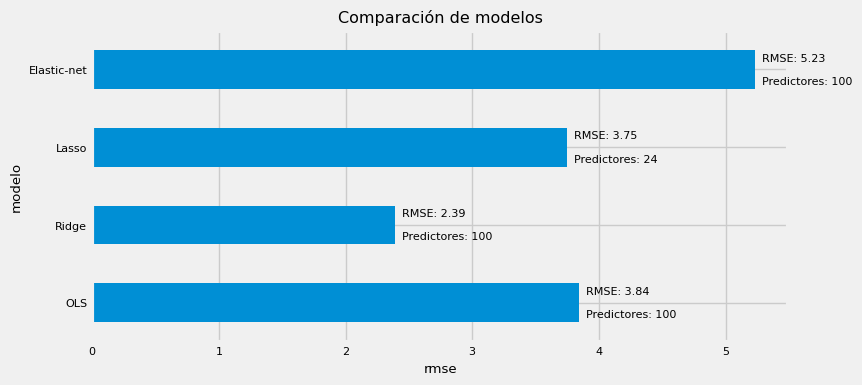

In [382]:
df_comparacion = pd.DataFrame({
    'modelo': ['OLS', 'Ridge', 'Lasso', 'Elastic-net'],
    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic],
    'predictores': [predictores_ols, predictores_ridge, predictores_lasso, predictores_elastic]
})

fig, ax = plt.subplots(figsize=(8, 3.84))

df_comparacion.set_index('modelo')['test rmse'].plot(kind='barh', ax=ax)

ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos')

for Index, Row in df_comparacion.iterrows():
    ax.text(
        Row['test rmse'],
        Index,
        f"  RMSE: {Row['test rmse']:.2f}\n\n  Predictores: {Row['predictores']}",
        va='center'
    )

plt.show()

In [383]:
# Conteo correcto como artículo
n_predictores_elastic = np.sum(modelo.coef_ != 0)  # O len(df_coeficientes[df_coeficientes.coef != 0])
print(f"Predictores ElasticNet (coef != 0): {n_predictores_elastic}")  # Debe dar 22
print()
# Tabla top coeficientes no cero
df_activos = df_coeficientes[df_coeficientes.coef != 0].sort_values('coef', key=abs, ascending=False)
print(df_activos.head(10))

Predictores ElasticNet (coef != 0): 100

   predictor       coef
0         V1  57.476210
45       V46 -40.863734
46       V47 -38.859561
44       V45 -37.159560
47       V48 -31.496736
43       V44 -28.501891
48       V49 -22.114699
32       V33  21.733533
31       V32  21.720782
37       V38  21.453889


**Conclusiones del artículo: (no coincido)**

* En este caso el mejor modelo en términos de error predictivo se obtiene aplicando regularización Ridge.

* El modelo con regularización Lasso tiene un error ligeramente superior al modelo OLS pero emplea solo 24 predictores en lugar de 100, ofreciendo un buen balance entre precisión e interpretabilidad.

* La regularización Elastic-net ofrece el modelo más simple (22 predictores) pero con mayor error.

---

**Conclusiones mías:**

* **Lasso** fue el modelo que elegí porque ofrece el mejor equilibrio entre capacidad predictiva e interpretabilidad. Si bien obtuvo un RMSE mayor que Ridge, logró reducir la cantidad de predictores de 100 a solo 24. Esto permite trabajar con un modelo mucho más simple, más fácil de interpretar y centrado en las variables que realmente aportan información relevante.

* **Ridge** fue el mejor modelo en términos estrictamente predictivos, ya que obtuvo el menor RMSE de todos los modelos evaluados. Sin embargo, mantuvo activos los 100 predictores, porque Ridge reduce el tamaño de los coeficientes, pero no los lleva exactamente a cero. Por ese motivo, aunque logró el menor error, no simplificó el modelo.

* **OLS** logró un desempeño intermedio, pero al no utilizar regularización, mantiene los 100 predictores originales y es más propenso al overfitting, especialmente en un conjunto de datos con muchas variables altamente correlacionadas.

* **Elastic Net** obtuvo el mayor RMSE en esta ejecución y, además, mantuvo activos los 100 predictores. Aunque combina características de Ridge y Lasso, en este caso no logró mejorar ni la precisión ni la simplificación del modelo.

**Por lo tanto, elijo Lasso como modelo final, ya que sacrifica una pequeña parte de precisión respecto a Ridge, pero obtiene un modelo mucho más simple e interpretable al conservar únicamente 24 predictores.**

---

**Discrepamos. ¿Quién "falla"?**

Nadie.

El artículo reporta el resultado concreto de su ejecución con los hiperparámetros que eligió ElasticNetCV en ese momento. Y yo estoy obteniendo un resultado equivalente pero ligeramente distinto (lo cual es común en estos modelos, sobre todo cerca del límite lasso).

**¿Por qué el artículo dice "22 predictores"?**

El artículo NO muestra el código ni la tabla de coeficientes de Elastic Net.

Solo muestra la gráfica de barras y afirma que usa 22 predictores.

> Para replicar exactamente los 22 del artículo, se necesitaría usar exactamente la misma versión de scikit-learn, el mismo orden en las filas del dataset y el mismo random_state en todos los pasos donde exista aleatoriedad. En ciencia de datos, estas pequeñas variaciones son normales y esperadas.